In [24]:
import numpy as np
import matplotlib.pyplot as plt

from classy import Class
from scipy.interpolate import interp1d
from scipy.integrate import simpson

In [25]:
# ============================================================
# User options
# ============================================================

flag_save_plot = False

# Ly-alpha redshift bins used for the diagnostic
z_lya_list = [3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2]

# CLASS pk(k,z) uses k in 1/Mpc and returns P in Mpc^3
k_grid_1Mpc = np.logspace(-3, np.log10(5.0), 500)

# For now k_parallel is also in 1/Mpc.
# Later, BOSS k_parallel[s/km] should be converted to 1/Mpc.
kpar_grid_1Mpc = np.logspace(-2, np.log10(2.0), 120)

# Linear Ly-alpha effective parameters.
# For ratios, A cancels if kept the same for LCDM and monopoles.
A_lya = 1.0
beta_lya = 1.4

In [26]:
# ============================================================
# Base cosmology
# ============================================================

base = {
    "100*theta_s": 1.04077,
    "omega_b": 0.02225,
    "omega_cdm": 0.1198,
    "tau_reio": 0.0790,
    "ln10^{10}A_s": 3.094,
    "n_s": 0.9645,

    "output": "mPk",
    "non_linear": "none",
    "P_k_max_1/Mpc": 6.0,
    "z_pk": ",".join(str(z) for z in z_lya_list),
}


In [27]:
# ============================================================
# Monopole benchmark models
# ============================================================

a_t = 1.0 / (40.0 + 1.0)
f_mon = 0.05

cases = [
    {
        "label": r"$\kappa=10$",
        "color": "#0072B2",
        "ls": "-",
        "params": {
            "f_mon": f_mon,
            "kappa_mon": 10.0,
            "a_t_mon": a_t,
        },
    },
    {
        "label": r"$\kappa=7.3077$",
        "color": "#D55E00",
        "ls": "--",
        "params": {
            "f_mon": f_mon,
            "kappa_mon": 7.3077,
            "a_t_mon": 1/(1+3),
        },
    },
]

In [28]:
# ============================================================
# CLASS helper
# ============================================================

def compute_pklin_grid(
    base_params,
    k_grid_1Mpc,
    z_list,
    monopole_params=None,
    gauge="synchronous",
):
    """
    Compute linear P(k,z) for LCDM or monopoles.

    CLASS convention:
        pk_lin(k,z) expects k in 1/Mpc
        pk_lin(k,z) returns P in Mpc^3
    """

    cosmo = Class()

    settings = dict(base_params)
    settings["gauge"] = gauge
    settings["output"] = "mPk"
    settings["non_linear"] = "none"
    settings["P_k_max_1/Mpc"] = float(np.max(k_grid_1Mpc) * 1.2)
    settings["z_pk"] = ",".join(str(z) for z in z_list)

    if monopole_params is not None:
        settings.update(monopole_params)

    try:
        cosmo.set(settings)
        cosmo.compute()

        P_by_z = {}

        for z in z_list:
            P_by_z[z] = np.array([
                cosmo.pk_lin(float(k), float(z))
                for k in k_grid_1Mpc
            ])

        derived = {
            "h": cosmo.h(),
            "H0": 100.0 * cosmo.h(),
            "Omega_m": cosmo.Omega_m(),
            "sigma8": cosmo.sigma8(),
            "S8": cosmo.sigma8() * np.sqrt(cosmo.Omega_m() / 0.3),
        }

        return P_by_z, derived

    finally:
        try:
            cosmo.struct_cleanup()
        except Exception:
            pass
        try:
            cosmo.empty()
        except Exception:
            pass

In [29]:
# ============================================================
# Linear Ly-alpha 1D flux proxy
# ============================================================

def linear_flux_1d_from_Plin(
    k_grid_1Mpc,
    P_grid_Mpc3,
    kpar_grid_1Mpc,
    beta=1.4,
    A=1.0,
    kmax_1Mpc=None,
):
    """
    Linear effective Ly-alpha 1D flux power.

    Model:
        P_F^lin(k, mu, z)
        =
        A * (1 + beta * mu^2)^2 * P_lin(k,z)

    Projection:
        P_F^1D(k_parallel,z)
        =
        1/(2*pi) * integral_{k_parallel}^{kmax} k dk P_F(k,mu,z)

    where:
        mu = k_parallel / k

    This is a diagnostic proxy, not yet a full BOSS likelihood.
    """

    k_grid_1Mpc = np.asarray(k_grid_1Mpc)
    P_grid_Mpc3 = np.asarray(P_grid_Mpc3)
    kpar_grid_1Mpc = np.asarray(kpar_grid_1Mpc)

    if kmax_1Mpc is None:
        kmax_1Mpc = np.max(k_grid_1Mpc)

    valid = (
        np.isfinite(k_grid_1Mpc)
        & np.isfinite(P_grid_Mpc3)
        & (k_grid_1Mpc > 0.0)
        & (P_grid_Mpc3 > 0.0)
    )

    logP_interp = interp1d(
        np.log(k_grid_1Mpc[valid]),
        np.log(P_grid_Mpc3[valid]),
        kind="cubic",
        bounds_error=False,
        fill_value="extrapolate",
    )

    P1D = []

    for kpar in kpar_grid_1Mpc:
        if kpar <= 0.0 or kpar >= kmax_1Mpc:
            P1D.append(np.nan)
            continue

        k_int = np.logspace(
            np.log10(kpar),
            np.log10(kmax_1Mpc),
            1000,
        )

        P_int = np.exp(logP_interp(np.log(k_int)))

        mu = kpar / k_int
        flux_factor = A * (1.0 + beta * mu**2)**2

        integrand = k_int * flux_factor * P_int

        P1D_val = simpson(integrand, x=k_int) / (2.0 * np.pi)
        P1D.append(P1D_val)

    return np.asarray(P1D)

In [30]:
# ============================================================
# Compute LCDM
# ============================================================

P_lcdm_by_z, derived_lcdm = compute_pklin_grid(
    base_params=base,
    k_grid_1Mpc=k_grid_1Mpc,
    z_list=z_lya_list,
    monopole_params=None,
    gauge="synchronous",
)

print("=" * 80)
print("LCDM")
for key, value in derived_lcdm.items():
    print(f"{key:10s} = {value}")
print("=" * 80)


LCDM
h          = 0.6745660167749372
H0         = 67.45660167749372
Omega_m    = 0.312170831332569
sigma8     = 0.8435976765014985
S8         = 0.8605396944895373


In [31]:
# ============================================================
# Compute monopole models
# ============================================================

models = []

for case in cases:
    P_mono_by_z, derived_mono = compute_pklin_grid(
        base_params=base,
        k_grid_1Mpc=k_grid_1Mpc,
        z_list=z_lya_list,
        monopole_params=case["params"],
        gauge="synchronous",
    )

    models.append({
        "label": case["label"],
        "color": case["color"],
        "ls": case["ls"],
        "params": case["params"],
        "P_by_z": P_mono_by_z,
        "derived": derived_mono,
    })

    print(case["label"])
    print("params =", case["params"])
    for key, value in derived_mono.items():
        print(f"{key:10s} = {value}")
    print()


$\kappa=10$
params = {'f_mon': 0.05, 'kappa_mon': 10.0, 'a_t_mon': 0.024390243902439025}
h          = 0.6915858024587936
H0         = 69.15858024587936
Omega_m    = 0.29699497401649727
sigma8     = 0.8530386928377343
S8         = 0.8487556011134872

$\kappa=7.3077$
params = {'f_mon': 0.05, 'kappa_mon': 7.3077, 'a_t_mon': 0.25}
h          = 0.6610306532013444
H0         = 66.10306532013443
Omega_m    = 0.3250858303181536
sigma8     = 0.8533890919466098
S8         = 0.8883528092875234



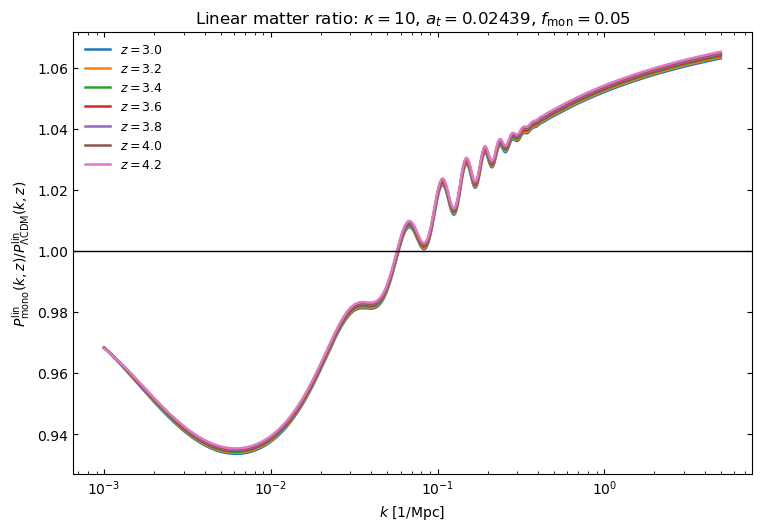

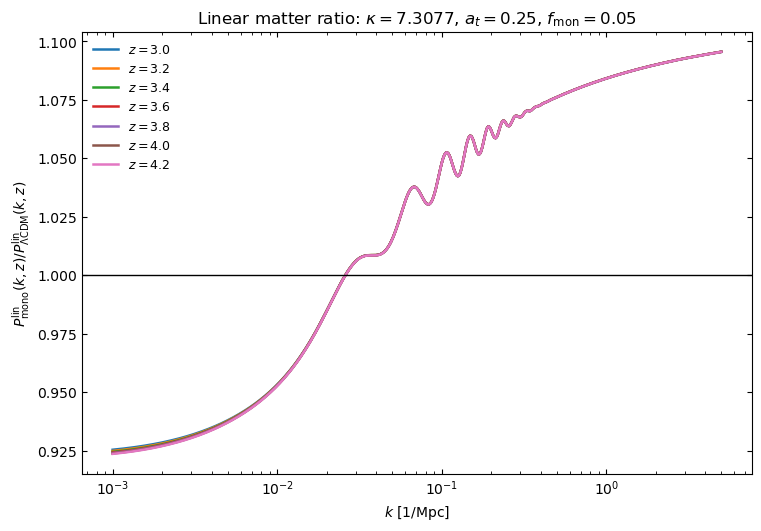

In [32]:
# ============================================================
# Plot 1: Linear matter power ratio
# ============================================================

for model in models:
    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)

    for z in z_lya_list:
        P_lcdm = P_lcdm_by_z[z]
        P_mono = model["P_by_z"][z]

        valid = (
            np.isfinite(P_lcdm)
            & np.isfinite(P_mono)
            & (P_lcdm > 0.0)
        )

        ratio = P_mono[valid] / P_lcdm[valid]

        ax.plot(
            k_grid_1Mpc[valid],
            ratio,
            lw=1.8,
            label=rf"$z={z:.1f}$",
        )

    ax.axhline(1.0, color="black", lw=1.0)
    ax.set_xscale("log")
    ax.set_xlabel(r"$k\ [1/{\rm Mpc}]$")
    ax.set_ylabel(
        r"$P_{\rm mono}^{\rm lin}(k,z)"
        r"/P_{\Lambda{\rm CDM}}^{\rm lin}(k,z)$"
    )

    ax.set_title(
        rf"Linear matter ratio: {model['label']}, "
        rf"$a_t={model['params']['a_t_mon']:.4g}$, "
        rf"$f_{{\rm mon}}={model['params']['f_mon']}$"
    )

    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=9)

    if flag_save_plot:
        filename = (
            "linear_matter_ratio_"
            + model["label"].replace("$", "").replace("\\", "").replace("=", "")
            + ".pdf"
        )
        fig.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

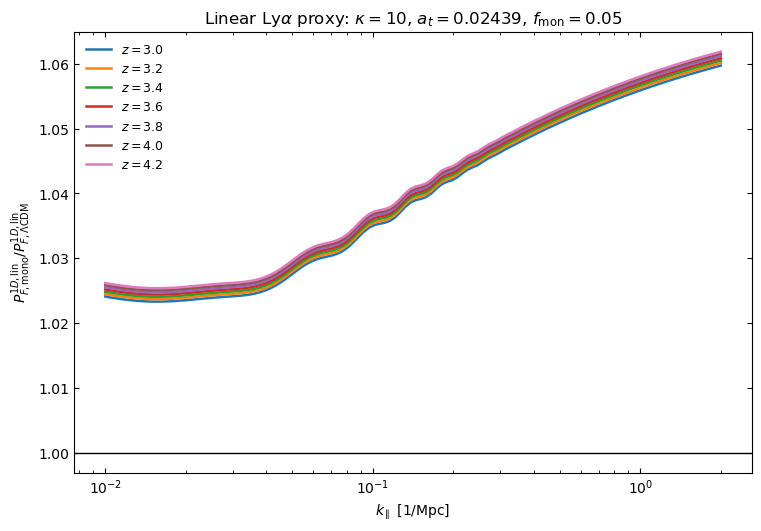

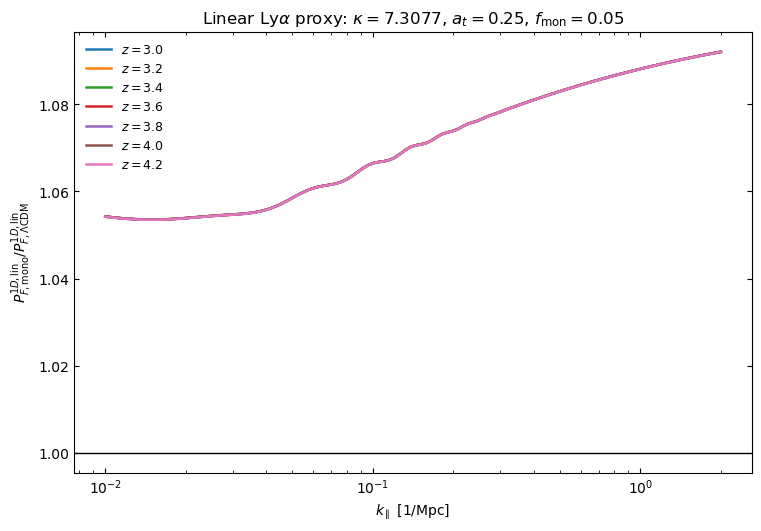

In [33]:
# ============================================================
# Plot 2: Linear Ly-alpha 1D flux proxy ratio
# ============================================================

for model in models:
    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)

    for z in z_lya_list:
        P_lcdm = P_lcdm_by_z[z]
        P_mono = model["P_by_z"][z]

        PF1D_lcdm = linear_flux_1d_from_Plin(
            k_grid_1Mpc=k_grid_1Mpc,
            P_grid_Mpc3=P_lcdm,
            kpar_grid_1Mpc=kpar_grid_1Mpc,
            beta=beta_lya,
            A=A_lya,
            kmax_1Mpc=k_grid_1Mpc.max(),
        )

        PF1D_mono = linear_flux_1d_from_Plin(
            k_grid_1Mpc=k_grid_1Mpc,
            P_grid_Mpc3=P_mono,
            kpar_grid_1Mpc=kpar_grid_1Mpc,
            beta=beta_lya,
            A=A_lya,
            kmax_1Mpc=k_grid_1Mpc.max(),
        )

        valid = (
            np.isfinite(PF1D_lcdm)
            & np.isfinite(PF1D_mono)
            & (PF1D_lcdm > 0.0)
        )

        ratio = PF1D_mono[valid] / PF1D_lcdm[valid]

        ax.plot(
            kpar_grid_1Mpc[valid],
            ratio,
            lw=1.8,
            label=rf"$z={z:.1f}$",
        )

    ax.axhline(1.0, color="black", lw=1.0)
    ax.set_xscale("log")
    ax.set_xlabel(r"$k_\parallel\ [1/{\rm Mpc}]$")
    ax.set_ylabel(
        r"$P_{F,\rm mono}^{1D,\rm lin}"
        r"/P_{F,\Lambda{\rm CDM}}^{1D,\rm lin}$"
    )

    ax.set_title(
        rf"Linear Ly$\alpha$ proxy: {model['label']}, "
        rf"$a_t={model['params']['a_t_mon']:.4g}$, "
        rf"$f_{{\rm mon}}={model['params']['f_mon']}$"
    )

    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=9)

    if flag_save_plot:
        filename = (
            "linear_lya_flux_proxy_ratio_"
            + model["label"].replace("$", "").replace("\\", "").replace("=", "")
            + ".pdf"
        )
        fig.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

In [34]:
def get_Hz_dict(base_params, z_list, monopole_params=None, gauge="synchronous"):
    """
    Return H(z) in km/s/Mpc for requested redshifts.
    """
    cosmo = Class()

    settings = dict(base_params)
    settings["gauge"] = gauge
    settings["output"] = "mPk"

    if monopole_params is not None:
        settings.update(monopole_params)

    cosmo.set(settings)
    cosmo.compute()

    Hz = {}
    for z in z_list:
        bg = cosmo.get_background()
        z_bg = np.asarray(bg["z"])
        H_bg = np.asarray(bg["H [1/Mpc]"])

        # interpolate H(z) in 1/Mpc
        H_1Mpc = np.interp(z, z_bg[::-1], H_bg[::-1])

        # convert 1/Mpc -> km/s/Mpc
        # H_class [1/Mpc] = H / c
        c_km_s = 299792.458
        Hz[z] = H_1Mpc * c_km_s

    try:
        cosmo.struct_cleanup()
    except Exception:
        pass
    try:
        cosmo.empty()
    except Exception:
        pass

    return Hz

In [35]:
kpar_skm = np.linspace(0.001, 0.02, 80)

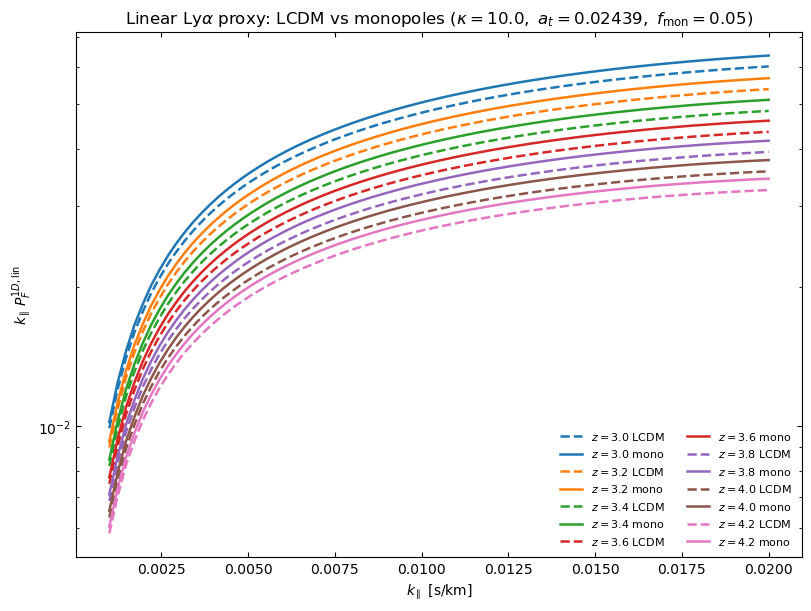

In [36]:
fig, ax = plt.subplots(figsize=(8.0, 6.0), constrained_layout=True)

# H(z) for LCDM
Hz_lcdm = get_Hz_dict(base, z_lya_list, monopole_params=None)

# choose one monopole model, e.g. first one
model = models[0]
Hz_mono = get_Hz_dict(base, z_lya_list, monopole_params=model["params"])

for i, z in enumerate(z_lya_list):
    color = plt.cm.tab10(i % 10)

    # Convert k_parallel [s/km] -> [1/Mpc]
    kpar_1Mpc_lcdm = kpar_skm * Hz_lcdm[z] / (1.0 + z)
    kpar_1Mpc_mono = kpar_skm * Hz_mono[z] / (1.0 + z)

    # Compute linear 1D flux proxy
    PF1D_lcdm = linear_flux_1d_from_Plin(
        k_grid_1Mpc=k_grid_1Mpc,
        P_grid_Mpc3=P_lcdm_by_z[z],
        kpar_grid_1Mpc=kpar_1Mpc_lcdm,
        beta=beta_lya,
        A=A_lya,
        kmax_1Mpc=k_grid_1Mpc.max(),
    )

    PF1D_mono = linear_flux_1d_from_Plin(
        k_grid_1Mpc=k_grid_1Mpc,
        P_grid_Mpc3=model["P_by_z"][z],
        kpar_grid_1Mpc=kpar_1Mpc_mono,
        beta=beta_lya,
        A=A_lya,
        kmax_1Mpc=k_grid_1Mpc.max(),
    )

    # Plot k_parallel * P_F^1D
    y_lcdm = kpar_skm * PF1D_lcdm
    y_mono = kpar_skm * PF1D_mono

    ax.plot(
        kpar_skm,
        y_lcdm,
        color=color,
        ls="--",
        lw=1.8,
        label=rf"$z={z:.1f}$ LCDM"
    )

    ax.plot(
        kpar_skm,
        y_mono,
        color=color,
        ls="-",
        lw=1.8,
        label=rf"$z={z:.1f}$ mono"
    )

ax.set_yscale("log")
ax.set_xlabel(r"$k_\parallel\ [{\rm s/km}]$")
ax.set_ylabel(r"$k_\parallel\,P_F^{1D,\rm lin}$")
ax.set_title(
    rf"Linear Ly$\alpha$ proxy: LCDM vs monopoles "
    rf"($\kappa={model['params']['kappa_mon']},\ "
    rf"a_t={model['params']['a_t_mon']:.4g},\ "
    rf"f_{{\rm mon}}={model['params']['f_mon']}$)"
)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.legend(frameon=False, fontsize=8, ncol=2)

plt.show()